# EDA — Anemia Dataset

**Nguồn**: Kaggle `biswaranjanrao/anemia-dataset`, lấy qua repo GitHub `maladeep/anemia-detection-with-machine-learning`.

**File**: `Data/tabular/anemia_ml_basic_repo/anemia data from Kaggle.csv` — 1.421 dòng × 6 cột: Gender, Hemoglobin, MCH, MCHC, MCV, Result (nhãn nhị phân).

Mục tiêu EDA: kiểm tra trùng lặp, phân phối nhãn, mối liên hệ Hemoglobin theo Gender/Result.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
DATA = Path(r'D:\AI_08_V1\Data')

df = pd.read_csv(DATA / 'tabular' / 'anemia_ml_basic_repo' / 'anemia data from Kaggle.csv')
print('Shape:', df.shape)
print('Missing values:', df.isna().sum().sum())
print('Dòng trùng lặp:', df.duplicated().sum(), f"({df.duplicated().sum()/len(df)*100:.1f}%)")
df_unique = df.drop_duplicates()
print('Sau khi loại trùng:', df_unique.shape)
df.head()

Shape: (1421, 6)
Missing values: 0
Dòng trùng lặp: 887 (62.4%)
Sau khi loại trùng: (534, 6)


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


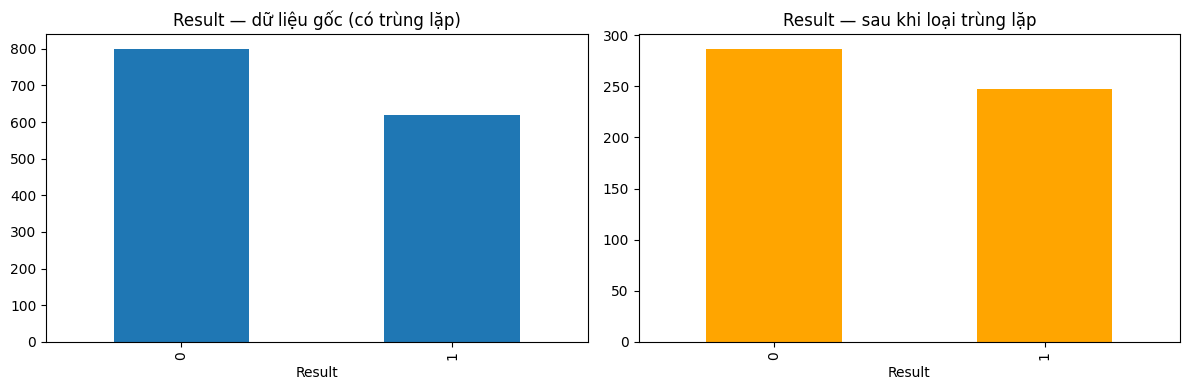

Phân bố gốc:
 Result
0    0.564
1    0.436
Name: proportion, dtype: float64

Phân bố sau loại trùng:
 Result
0    0.537
1    0.463
Name: proportion, dtype: float64


In [2]:
# Phân bố nhãn trước/sau khi loại trùng lặp
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Result'].value_counts().plot.bar(ax=axes[0], title='Result — dữ liệu gốc (có trùng lặp)')
df_unique['Result'].value_counts().plot.bar(ax=axes[1], title='Result — sau khi loại trùng lặp', color='orange')
plt.tight_layout()
plt.show()

print('Phân bố gốc:\n', df['Result'].value_counts(normalize=True).round(3))
print('\nPhân bố sau loại trùng:\n', df_unique['Result'].value_counts(normalize=True).round(3))

                mean   min   max  count
Gender Result                          
0      0       14.46  12.0  16.9    473
       1       10.95   6.6  11.9    208
1      0       15.28  13.5  16.9    328
       1       11.97   9.0  13.4    412


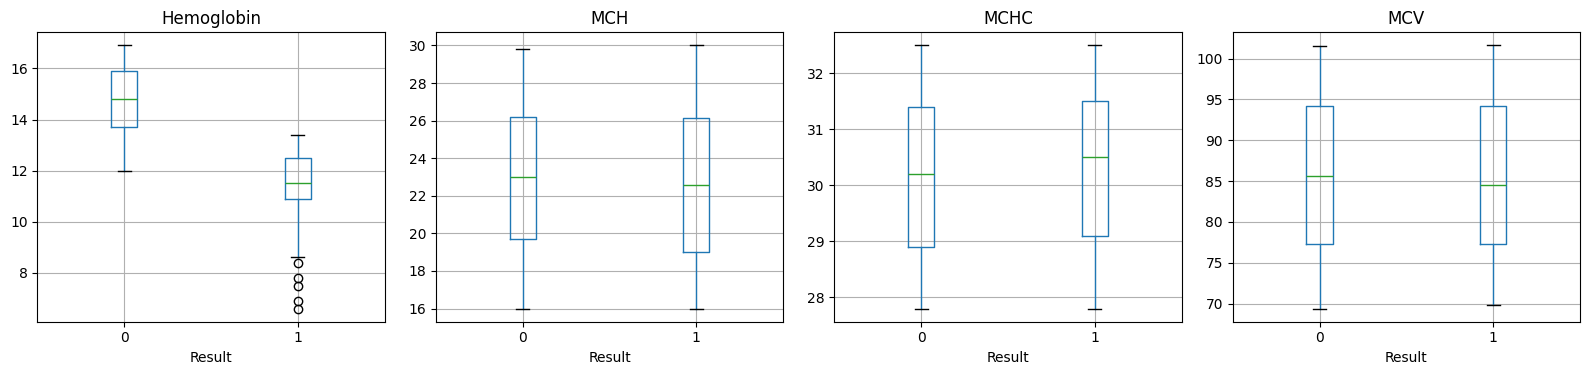

In [3]:
# Hemoglobin theo Gender x Result + phân phối các chỉ số
print(df.groupby(['Gender', 'Result'])['Hemoglobin'].agg(['mean', 'min', 'max', 'count']).round(2))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['Hemoglobin', 'MCH', 'MCHC', 'MCV']):
    df.boxplot(column=col, by='Result', ax=ax)
    ax.set_title(col)
plt.suptitle('')
plt.tight_layout()
plt.show()

## Nhận xét

- Không có missing value.
- **Trùng lặp nặng: 887/1.421 dòng (62.4%)** — sau loại trùng chỉ còn ~534 dòng thật sự khác nhau; cần tính lại phân bố nhãn trên dữ liệu đã loại trùng trước khi dùng train/test.
- Chỉ có 5 feature huyết học — đủ phân biệt có/không thiếu máu, không đủ phân loại 9 loại thiếu máu riêng biệt.
- Hemoglobin ở nhóm Result=1 thấp hơn rõ rệt ở cả 2 giới — xu hướng hợp lý về lâm sàng, cho thấy nhãn đáng tin cậy.